#General Data Preparation

In this notebook, we perform the general data preparation steps required for the project.

These include:

* Reading raw ECG signals from WFDB files and matching them with the corresponding metadata
* Removing ECG recordings with electrode-related problems
* Applying a Butterworth band-pass filter to reduce noise
* Creating the final cleaned metadata dataframe
* Splitting the data into training, validation, and test sets
* Normalizing ECG signals using the mean and standard deviation computed from the training set
* Performing signal segmentation using 3-second windows with 50% overlap
* Saving the processed arrays and normalization statistics for later model training and inference


## Importing modules and libraries


In [1]:
%pip install wfdb
%pip install dash

import numpy as np
import pandas as pd
import ast
import wfdb
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch
from tqdm import tqdm
import os

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 57.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 54.3 MB/s eta 0:00:00


## Storing data into Collab Session

In order to make data loading faster, we load data directly into the Collab session. (Only 100hz version).

**This cell should be runned just for the first time**

In [2]:
# !cp -r "/content/drive/MyDrive/AI_in_Medicine_Project/Dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/records100" "/content/ptbxl100"

## Data paths

In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_BASE = "/content/drive/MyDrive/AI_in_Medicine_Project/Dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/"
ECG_FILES = "/content/drive/MyDrive/AI_in_Medicine_Project/Dataset/X_ptbxl_full.npy"

OUTPUT_DIR = "/content/drive/MyDrive/AI_in_Medicine_Project/DL Part/processed_dataset/"


Mounted at /content/drive


## Exploratory Data Analysis (EDA)

# **1. Loading metadata**


In [4]:
def aggregate_labels(scp_dict):
    labels = []
    for code, conf in scp_dict.items():
        if code in agg_df.index:
            sc = agg_df.loc[code, 'diagnostic_class']
            if sc in SUPERCLASSES and conf >= 50:
                labels.append(sc)
    return list(set(labels))

df = pd.read_csv(f'{PROJECT_BASE}/ptbxl_database.csv', index_col='ecg_id') #original csv file, each subject each row

df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval) #converting string to dict

agg_df = pd.read_csv(f'{PROJECT_BASE}/scp_statements.csv', index_col=0) #mapping for diagnosis
agg_df = agg_df[agg_df["diagnostic"] == 1]  # we only keep data for diagnosis

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP'] # superclasses defined by main documentation

SUPERCLASSES_DICT = {

    "NORM": "Normal ECG",
    "MI": "Myocardial Infarction",
    "STTC": "ST/T Change",
    "CD": "Conduction Disturbance",
    "HYP": "Hypertrophy"

}

df['labels'] = df["scp_codes"].apply(aggregate_labels)

### Checking superclass distributions

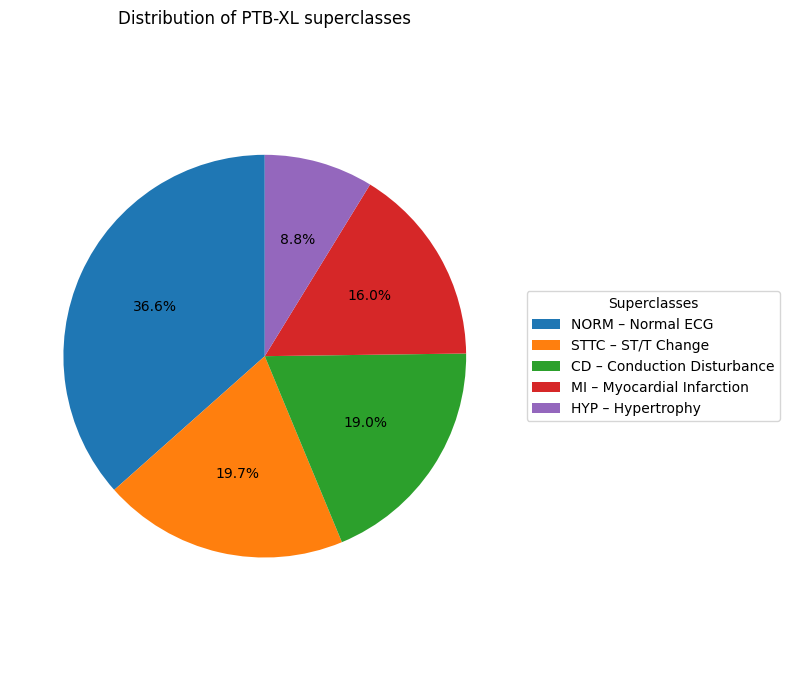

In [5]:

label_counts = df['labels'].explode().value_counts()

superclass_names = {
    "NORM": "Normal ECG",
    "MI":   "Myocardial Infarction",
    "STTC": "ST/T Change",
    "CD":   "Conduction Disturbance",
    "HYP":  "Hypertrophy",
}

legend_labels = [f"{c} – {superclass_names[c]}" for c in label_counts.index]

plt.figure(figsize=(8, 7))

wedges, texts, autotexts = plt.pie(
    label_counts,
    autopct='%1.1f%%',
    startangle=90
)

plt.legend(
    wedges,
    legend_labels,
    title="Superclasses",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title('Distribution of PTB-XL superclasses')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Observations:

- The dataset is imbalanced, with the NORM class being the most dominant category, representing approximately 36.6% of all ECG recordings.

- Since the dataset is not uniformly distributed, model training may become biased toward the majority classes, especially NORM.


# **2. Loading WFDB signals**

- In this part here, we load raw WFDB signals into an np array and save this array so we can reuse later.

- This cell shouldn't be rerunned!!

In [ ]:
# PROJECT_BASE = "/content/ptbxl/"
# filenames = df["filename_lr"]

# X = np.lib.format.open_memmap(
#     "/content/X_ptbxl_full.npy",
#     mode="w+",
#     dtype=np.float32,
#     shape=(len(filenames), 1000, 12)
# )

# for i, f in enumerate(filenames):
#     f = f.replace("records100/", "")
#     signal, _ = wfdb.rdsamp("/content/ptbxl100/" + f)
#     X[i] = signal.astype(np.float32)

#     if i % 1000 == 0:
#         print(i, "/", len(filenames))
# del X

# !cp "/content/X_ptbxl_full.npy" "/content/drive/MyDrive/AI_in_Medicine_Project/Dataset/X_ptbxl_full.npy"

0 / 21837
1000 / 21837
2000 / 21837
3000 / 21837
4000 / 21837
5000 / 21837
6000 / 21837
7000 / 21837
8000 / 21837
9000 / 21837
10000 / 21837
11000 / 21837
12000 / 21837
13000 / 21837
14000 / 21837
15000 / 21837
16000 / 21837
17000 / 21837
18000 / 21837
19000 / 21837
20000 / 21837
21000 / 21837


#### **Loading .npy file directly**

In [6]:
X = np.load(ECG_FILES)
print(f"Number of subjects in dataset: {df.shape[0]}")
print(f"For each subject there are {X.shape[2]} signals (leads) of duration {X.shape[1]/100} seconds")

Number of subjects in dataset: 21837
For each subject there are 12 signals (leads) of duration 10.0 seconds


### **Plotting ECG signals**

An ECG signal consists of 12 leads, each of which records the electrical activity of the heart from a different perspective. These leads can be plotted separately to analyze different parts of the cardiac cycle.

The first six leads (I, II, III, aVR, aVL, aVF) are limb leads (unipolar and bipolar), while
V1–V6 are precordial (chest) leads


In [7]:
LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
              'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

def plot_ecg(record,ind,  sampling_rate=100, df=None):
    """
    Plot all 12 leads of an ECG from the PTB-XL dataset.

    Args:
        record_path: Path to the record (without file extension)
        sampling_rate: 100 or 500 Hz (PTB-XL options)
        df: PTB-XL metadata DataFrame (used to look up diagnostic labels)
    """
    signal = record
    time = np.arange(signal.shape[0]) / sampling_rate

    # --- build title with superclass labels ---
    record_name = ""
    label_str = ""
    if df is not None:
        # match on filename
        col = "filename_lr" if sampling_rate == 100 else "filename_hr"
        match = df.loc[ind+1]
        if not match.empty:
            labels = match["labels"]
            label_str = "  |  " + ", ".join(
                SUPERCLASSES_DICT.get(l, l) for l in labels
            ) if labels else "  |  Unknown"

    fig, axes = plt.subplots(12, 1, figsize=(14, 16), sharex=True)
    fig.suptitle(f"ECG – {record_name}{label_str}", fontsize=13)

    for i, (ax, name) in enumerate(zip(axes, LEAD_NAMES)):
        ax.plot(time, signal[:, i], linewidth=0.8, color="black")
        ax.set_ylabel(name, rotation=0, labelpad=24, fontsize=9)
        ax.set_yticks([])
        ax.spines[["top", "right", "left"]].set_visible(False)

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

- Plotting of one ECG sample that is classified as NORMAL, and one which is classified as the one with Hyptertrophy and Conduction Distrubance

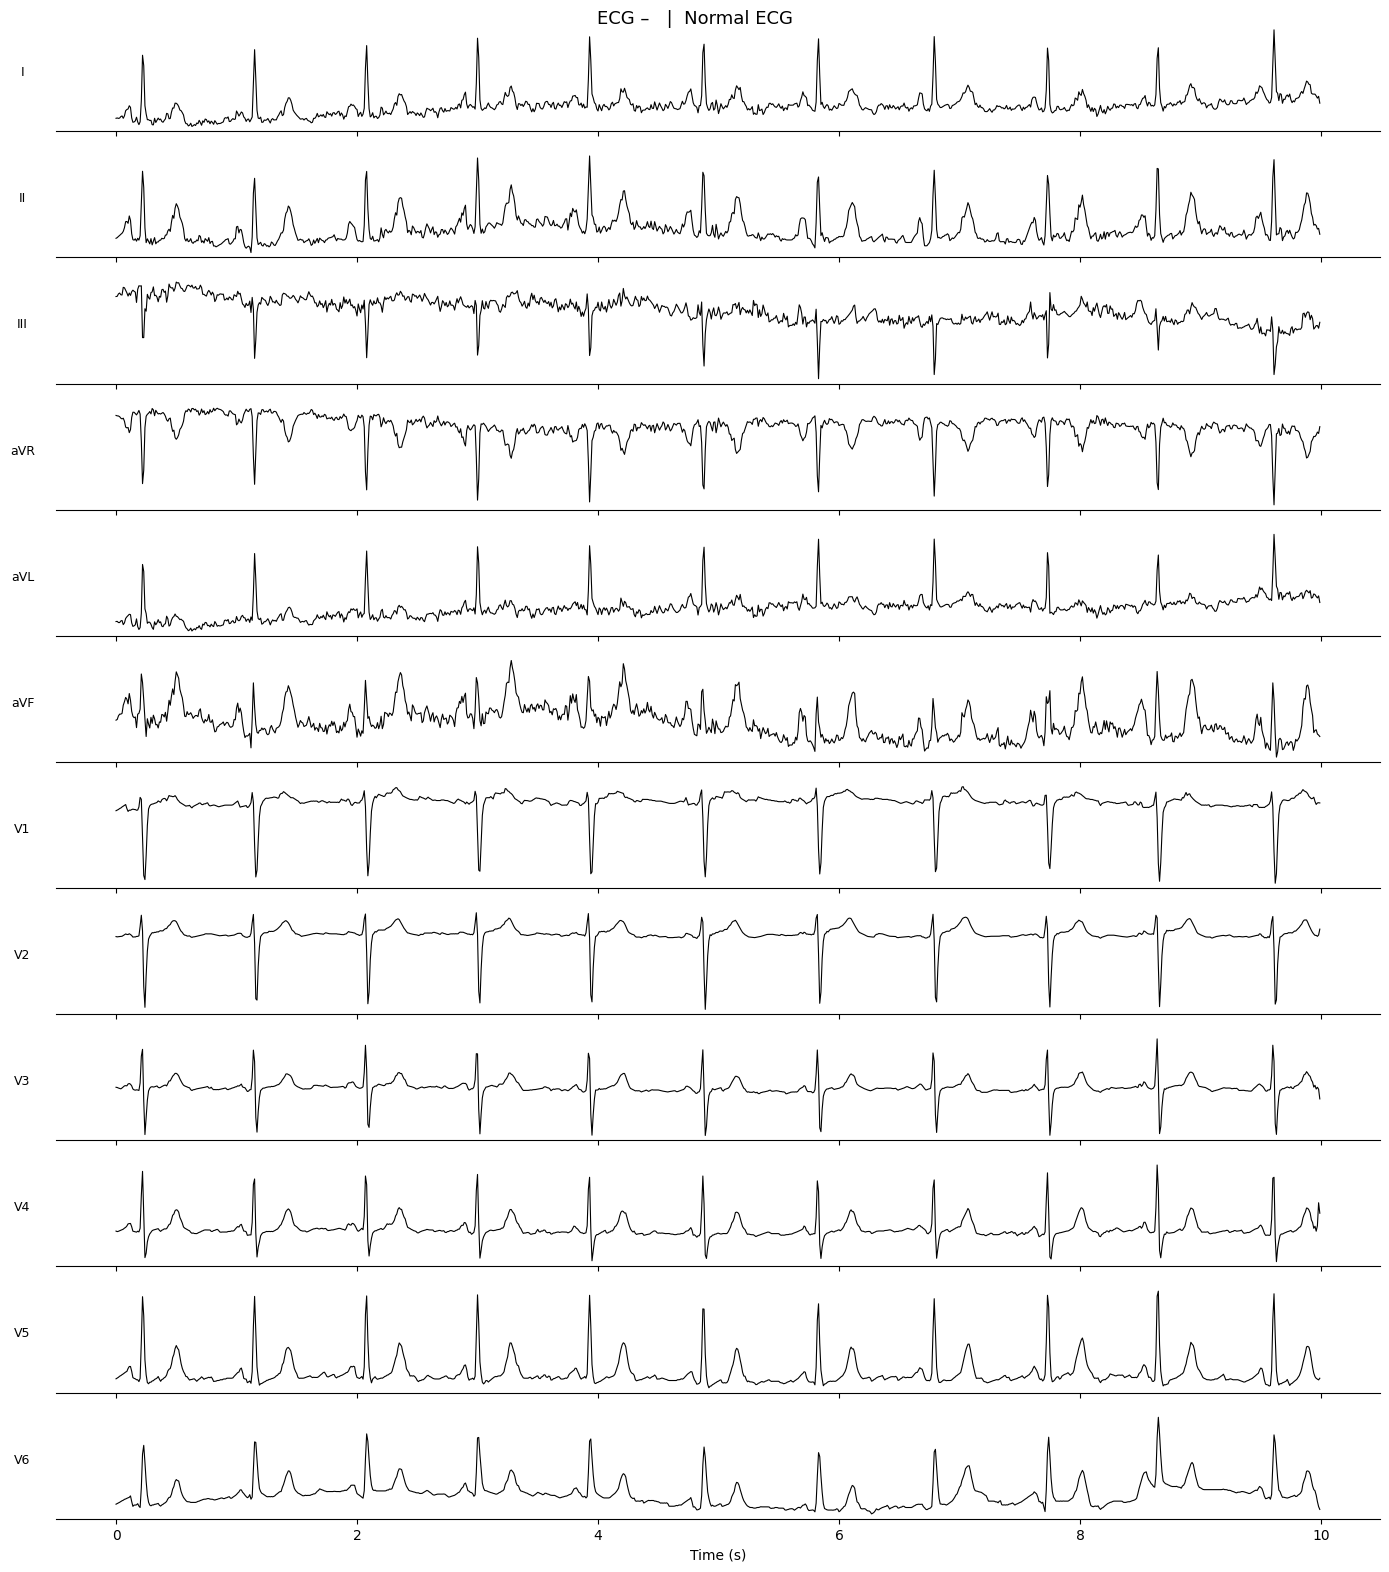

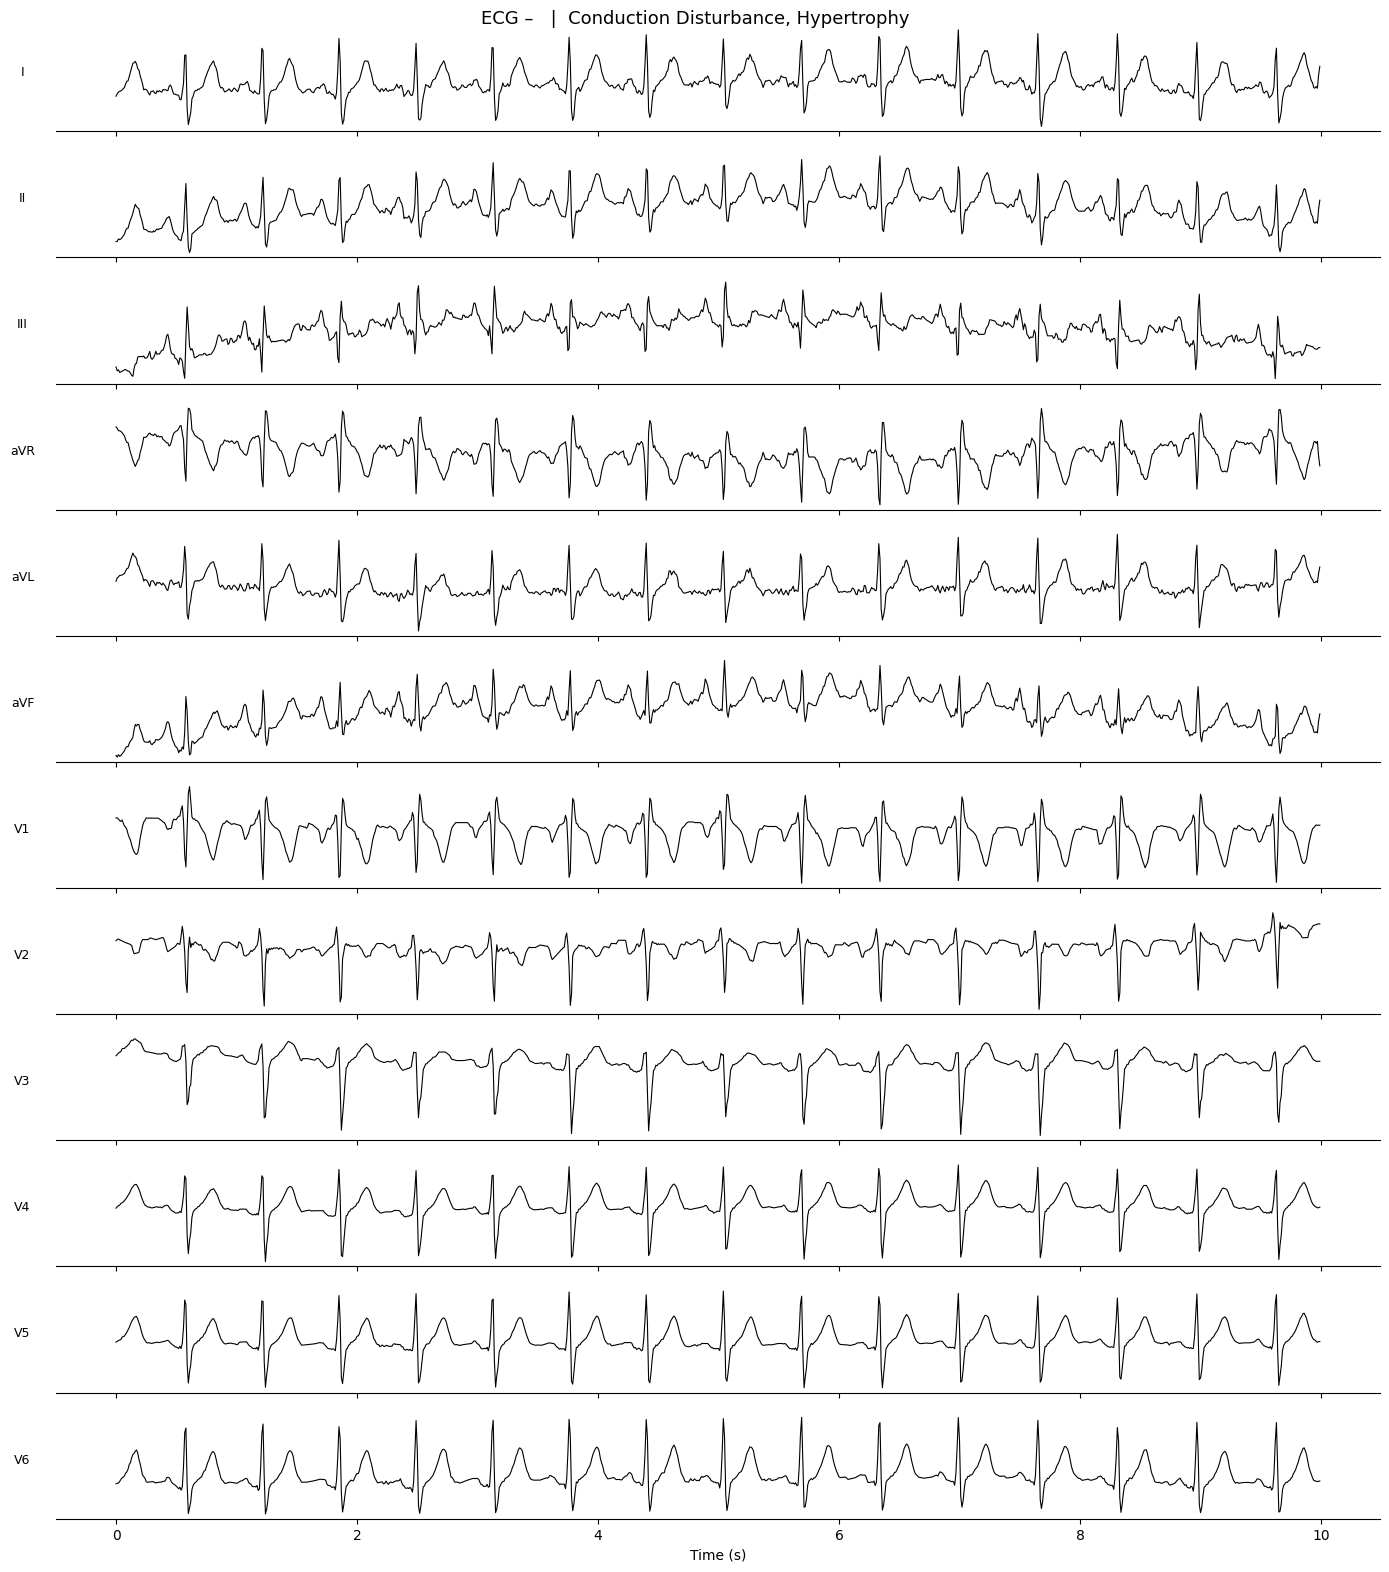

In [8]:
plot_ecg(X[0], 0, df=df) # Normal
plot_ecg(X[44], 44, df=df) #Hypertrophy, Conduction Disturbance

###



## **Data missing and preprocessing**

The PTB-XL metadata file provides information about the diagnostic category of each ECG record.

In [9]:
noise_cols = ["static_noise", "burst_noise", "baseline_drift",
              "electrodes_problems"] # 4 types of problems in ECG signals

print("=== Flag breakdown ===")
for col in noise_cols:
    n = df[col].notna().sum()
    print(f"  {col:25s}: {n:5d} ({100*n/len(df):.1f}%)")

has_any = df[noise_cols].notna().any(axis=1)
print(f"\n  Flagged (any)        : {has_any.sum()} ({100*has_any.mean():.1f}%)")
print(f"  Clean                : {(~has_any).sum()}")

=== Flag breakdown ===
  static_noise             :  3262 (14.9%)
  burst_noise              :   613 (2.8%)
  baseline_drift           :  1607 (7.4%)
  electrodes_problems      :    30 (0.1%)

  Flagged (any)        : 5021 (23.0%)
  Clean                : 16816


## **Observations**

The majority of records in the dataset do not have an assigned noise label.

Since only 30 records are marked as having electrode-related problems, these rows were removed from the dataset.

**Static noise** is also known as high-frequency noise. Typical causes for it are: EMG interference, electronic noise. Common approaches for dealing with it are low-pass filtering or band-pass filtering of the signals to range 0.5-40Hz.

**Baseline drift** is a low-frequency fluctuation of the ECG baseline, meaning that the entire ECG signal slowly moves up and down around the zero level. Baseline drift is a very low-frequency artifact, typically below: f < 0.5 Hz. Common approach for dealing with it is applying high-pass filtering < 0.5Hz.

**Burst noise** consists of short-duration, high-amplitude spikes or sudden disturbances in the ECG signal. Typical causes are electrode movement, temporary loss of electrode contact, motion artifacts, or transmission errors. Unlike static noise, burst noise occurs only in short segments of the recording and can severely distort the ECG waveform locally. Common approaches for dealing with it are applying a median filter or a Hampel filter to remove impulsive spikes, interpolating corrupted samples, or discarding heavily corrupted segments if the affected region is too large.

In [10]:
df_original = df.copy()  # keep original safe

mask_keep = df_original["electrodes_problems"].isna() # if there is no value, there is no problem with electrodes
df_final = df_original[mask_keep]

df_final["needs_filter"] = (
    df_final["static_noise"].notna() |
    df_final["burst_noise"].notna() |
    df_final["baseline_drift"].notna()
).astype(int)

print(f"Total original     : {len(df_original)}")
print(f"Dropped (electrode): {df_original['electrodes_problems'].notna().sum()}")
print(f"Final dataset      : {len(df_final)}")
print(f"  - needs filter   : {df_final['needs_filter'].sum()}")
print(f"  - already clean  : {(df_final['needs_filter'] == 0).sum()}")

X_final = X[mask_keep.values]


Total original     : 21837
Dropped (electrode): 30
Final dataset      : 21807
  - needs filter   : 4991
  - already clean  : 16816


### **Count NaN values**

In [11]:
def check_nan_values(X):
    # Check if there are any NaN values
    has_nan = np.isnan(X).any()

    print(f"Contains NaN values: {has_nan}")

    if has_nan:
        # Total number of NaNs
        total_nans = np.isnan(X).sum()
        print(f"Total NaN values: {total_nans}")

        # Indices where NaNs appear
        nan_indices = np.argwhere(np.isnan(X))

        print("First 10 NaN positions:")
        print(nan_indices[:10])

    return has_nan

In [12]:
check_nan_values(X)

Contains NaN values: False


np.False_

## Observations:
There are no missing values in the dataset.

# **Defining Filter Banks**

The proposed filtering pipeline is:
1. Band-pass filtering in the range 0.5–40 Hz for simultaneous removal of baseline drift and high-frequency noise.

In [13]:
from scipy.ndimage import median_filter


def bandpass_filter(signal, fs=100, low=0.5, high=40.0):
    """Combines highpass + lowpass in one step."""
    b, a = butter(4, [low / (fs / 2), high / (fs / 2)], btype="band")
    return filtfilt(b, a, signal, axis=0)

# def median_filter_ecg(signal, fs=100, ms=50):

#     k = max(3, int(round(ms * fs / 1000)))
#     if k % 2 == 0:                      # median window must be odd
#         k += 1

#     if signal.ndim == 1:
#         return median_filter(signal, size=k, mode="reflect")

#     # 2D: filter along time only, keep leads independent
#     return median_filter(signal, size=(k, 1), mode="reflect")

## Testing on a single sample

In [14]:
# records flagged for ALL THREE: static_noise AND burst_noise AND baseline_drift
all_three = (
    df_final["static_noise"].notna() &
    df_final["burst_noise"].notna() &
    df_final["baseline_drift"].notna()
)
pos = np.where(all_three.values)[0]

print(f"records with all three flags: {len(pos)}")

if len(pos) == 0:
    raise ValueError("no record carries all three flags - widen the criterion")

p = pos[0]                                          # positional index into X_final
sig = X_final[p]

print(f"row position {p}  (original df index {df_final.index[p]})")
print(f"  static_noise   : {df_final.iloc[p]['static_noise']!r}")
print(f"  burst_noise    : {df_final.iloc[p]['burst_noise']!r}")
print(f"  baseline_drift : {df_final.iloc[p]['baseline_drift']!r}")
print(f"  shape          : {sig.shape}")

records with all three flags: 10
row position 1242  (original df index 1249)
  static_noise   : ' , V1,  '
  burst_noise    : 'I-AVF'
  baseline_drift : ' , V1'
  shape          : (1000, 12)


In [20]:
def plot_ecg_compare(raw, filtered, ind, sampling_rate=100, df=None, label="", export_svg=False, svg_path=None):
    """plot_ecg, but with the raw signal overlaid (grey) behind the filtered (black)."""
    time = np.arange(raw.shape[0]) / sampling_rate

    label_str = ""
    if df is not None:
        match = df.loc[ind + 1]
        if not match.empty:
            labels = match["labels"]
            label_str = "  |  " + ", ".join(
                SUPERCLASSES_DICT.get(l, l) for l in labels
            ) if labels else "  |  Unknown"

    fig, axes = plt.subplots(12, 1, figsize=(14, 16), sharex=True)
    fig.suptitle(f"ECG – {label}{label_str}", fontsize=13)

    for i, (ax, name) in enumerate(zip(axes, LEAD_NAMES)):
        ax.plot(time, raw[:, i],      color="red", lw=0.8, label="raw"      if i == 0 else None)
        ax.plot(time, filtered[:, i], color="blue", lw=0.8, label="filtered" if i == 0 else None)
        ax.set_ylabel(name, rotation=0, labelpad=24, fontsize=9)
        ax.set_yticks([])
        ax.spines[["top", "right", "left"]].set_visible(False)

    axes[0].legend(loc="upper right", fontsize=8)
    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    if export_svg:
        if svg_path is None:
            safe_label = label.replace(" ", "_").replace("/", "-") if label else f"record_{ind}"
            svg_path = f"ecg_compare_{safe_label}.svg"
        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        print(f"SVG saved → {svg_path}")


    plt.show()

SVG saved → ecg_compare_BANDPASS_ONLY.svg


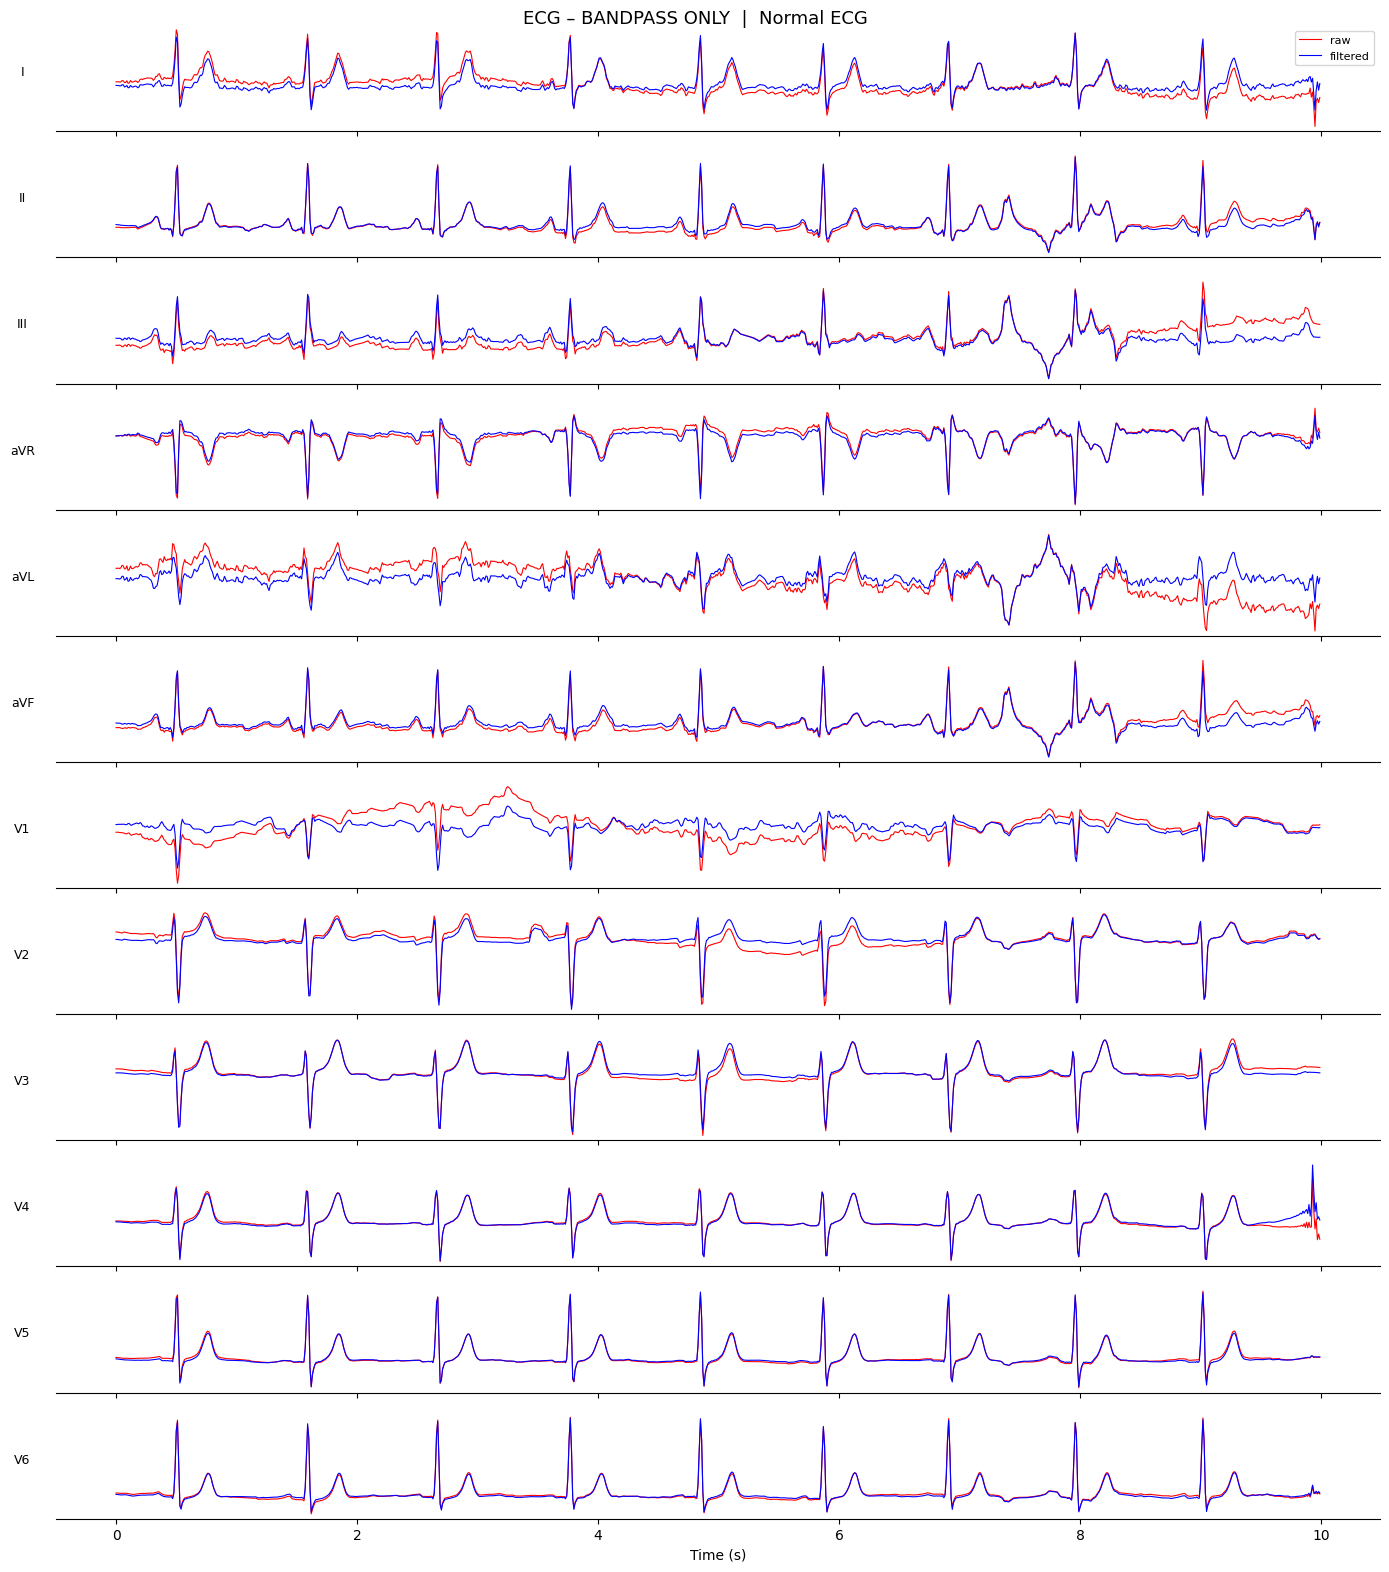

In [21]:
sig_band   = bandpass_filter(sig, fs=100)
# 1-based df so plot_ecg's df.loc[ind+1] resolves
df_plot = df_final.reset_index(drop=True)
df_plot.index = df_plot.index + 1
plot_ecg_compare(sig, sig_band,   p, df=df_plot, label="BANDPASS ONLY", export_svg=True)

In [22]:
X_clean = np.zeros_like(X_final)

for i, signal in enumerate(tqdm(X_final, total=len(X_final))):
    X_clean[i] = bandpass_filter(
        signal,
        fs=100,
    )

print(f"Done. Shape: {X_clean.shape}")
print(f"NaN after processing: {np.isnan(X_clean).sum()}")

100%|██████████| 21807/21807 [00:32<00:00, 666.56it/s] 


Done. Shape: (21807, 1000, 12)
NaN after processing: 0


# Encode Multi-Label Targets (MLB)

A single ECG recording can have multiple diagnoses at the same time. Therefore, the target variable cannot be represented as a single class label.

To handle this, we use **MultiLabelBinarizer (MLB)**, which converts the list of diagnoses for each ECG record into a binary vector. Each position in the vector represents one diagnostic class, where:

- `1` means that the diagnosis is present
- `0` means that the diagnosis is not present

This allows the model to learn the problem as a **multi-label classification task**, where multiple classes can be predicted for the same ECG signal.

In [ ]:
mlb = MultiLabelBinarizer(classes=SUPERCLASSES)
Y = mlb.fit_transform(df_final['labels'])

# Check label co-occurrence
print(pd.DataFrame(Y, columns=SUPERCLASSES).sum())

print(f"Resulting shape: {Y.shape}")

NORM    9442
MI      4137
STTC    5083
CD      4891
HYP     2260
dtype: int64
Resulting shape: (21807, 5)


## Train/Validation/Test Split

The PTB-XL dataset provides predefined folds for splitting the data into training, validation, and test sets. Using these official folds ensures that the evaluation procedure is consistent and that the obtained results can be fairly compared with other approaches.

In this project, the training set is used to fit the model, the validation set is used for model selection and hyperparameter tuning, and the test set is kept separate for the final performance evaluation.

In [ ]:
test_fold  = 10
val_fold   = 9

X_test  = X_clean[df_final.strat_fold == test_fold]
Y_test  = Y[df_final.strat_fold == test_fold]

X_val   = X_clean[df_final.strat_fold == val_fold]
Y_val   = Y[df_final.strat_fold == val_fold]

X_train = X_clean[df_final.strat_fold <= 8]
Y_train = Y[df_final.strat_fold <= 8]

## Z-standardization of Signals

Z-standardization is applied to normalize the ECG signals so that they have zero mean and unit variance. This helps reduce differences in signal amplitude between records and makes the input data more suitable for model training.

The mean and standard deviation are computed from the training set only, and the same values are then applied to the validation and test sets to avoid data leakage.



In [ ]:
# Z-score normalization per lead
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1), keepdims=True)

X_train = (X_train - mean) / (std + 1e-8)
X_val   = (X_val   - mean) / (std + 1e-8)
X_test  = (X_test  - mean) / (std + 1e-8)

np.save(f"{OUTPUT_DIR}/train/X_train.npy", X_train)
np.save(f"{OUTPUT_DIR}/val/X_val.npy", X_val)
np.save(f"{OUTPUT_DIR}/test/X_test.npy", X_test)

np.save(f"{OUTPUT_DIR}/train/Y_train.npy", Y_train)
np.save(f"{OUTPUT_DIR}/val/Y_val.npy", Y_val)
np.save(f"{OUTPUT_DIR}/test/Y_test.npy", Y_test)

## Signal Segmentation

First, the complete 10-second ECG signal is used as one input sample. This allows the model to learn global cardiac patterns from the entire recording.

Second, each ECG signal is divided into 3 second segments, with 50% overlap.. This increases the number of training samples and allows the model to learn more local ECG patterns.

In [ ]:
def segment_signal(signal, fs=100, window_sec=3, overlap=0.5):

    W    = int(window_sec * fs)          # window size in samples  → 500
    S    = int(W * (1 - overlap))        # step size in samples
    L    = signal.shape[0]               # total signal length

    segments = np.stack([
        signal[start : start + W]
        for start in range(0, L - W + 1, S)
    ])

    return segments


def segment_with_labels(X, Y, fs=100, window_sec=3, overlap=0.5):
    X_segments, Y_segments, record_ids = [], [], []

    for i in range(len(X)):
        segs = segment_signal(X[i], fs=fs, window_sec=window_sec, overlap=overlap)
        n    = len(segs)

        X_segments.append(segs)
        Y_segments.append(np.tile(Y[i], (n, 1)))
        record_ids.append(np.full(n, i))          # ← track which record each segment belongs to

    return (
        np.concatenate(X_segments),
        np.concatenate(Y_segments),
        np.concatenate(record_ids)
    )


X_train_seg, Y_train_seg, ids_train = segment_with_labels(X_train, Y_train)
X_val_seg,   Y_val_seg,   ids_val   = segment_with_labels(X_val,   Y_val)
X_test_seg,  Y_test_seg,  ids_test  = segment_with_labels(X_test,  Y_test)

print(f"Train : {X_train_seg.shape}, labels: {Y_train_seg.shape}")
print(f"Val   : {X_val_seg.shape}, labels: {Y_val_seg.shape}")
print(f"Test  : {X_test_seg.shape}, labels: {Y_test_seg.shape}")

# Create segment folders
for split in ["train", "val", "test"]:
    os.makedirs(f"{OUTPUT_DIR}/{split}/segments", exist_ok=True)

# Save segmented data
np.save(f"{OUTPUT_DIR}/train/segments/X_train_seg.npy", X_train_seg)
np.save(f"{OUTPUT_DIR}/train/segments/Y_train_seg.npy", Y_train_seg)
np.save(f"{OUTPUT_DIR}/train/segments/ids_train.npy", ids_train)

np.save(f"{OUTPUT_DIR}/val/segments/X_val_seg.npy", X_val_seg)
np.save(f"{OUTPUT_DIR}/val/segments/Y_val_seg.npy", Y_val_seg)
np.save(f"{OUTPUT_DIR}/val/segments/ids_val.npy", ids_val)

np.save(f"{OUTPUT_DIR}/test/segments/X_test_seg.npy", X_test_seg)
np.save(f"{OUTPUT_DIR}/test/segments/Y_test_seg.npy", Y_test_seg)
np.save(f"{OUTPUT_DIR}/test/segments/ids_test.npy", ids_test)

Train : (87090, 300, 12), labels: (87090, 5)
Val   : (10945, 300, 12), labels: (10945, 5)
Test  : (11000, 300, 12), labels: (11000, 5)


# **All further experiments will be performed only on the training and validation set in another notebooks.**